<a href="https://colab.research.google.com/github/kalex066/RegresionModels--UsedCars/blob/main/Core_UsedCars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis y Predicción de Precios de Autos Usados(Core)**

**Objetivo:** Aplicar técnicas de regresión lineal, KNN y árboles de decisión para predecir precios de autos utilizando un dataset de Kaggle.

Realizar un Análisis Exploratorio de Datos (EDA) completo y comparar el rendimiento de los modelos mediante benchmarking.


**Dataset:** [Used Cars Dataset — Kaggle (Austin Reese)](https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data)  

**Descripción del Dataset**: Este conjunto de datos contiene información detallada sobre precios, condicion, manufacturador, latitud/longitud y otras 18 categorias de autos usados en venta.

**Variable objetivo:** `price` (precio en USD) ·

**Dimensiones del Dataset** ~426.000 registros · 26 columnas de las cuales solo se cargaron **370.049** filas

**Diccionario de Datos**

| Columna | Descripción |
| :--- | :--- |
| **id** | Identificador único del anuncio. |
| **url** | Enlace directo a la publicación. |
| **region** | Ciudad o área geográfica de la publicación. |
| **price** | Precio de venta en USD (Variable objetivo). |
| **year** | Año de fabricación del vehículo. |
| **manufacturer** | Marca del vehículo (ej. Toyota, Ford). |
| **model** | Modelo específico del vehículo. |
| **condition** | Estado físico (excelente, bueno, nuevo, salvage). |
| **cylinders** | Cantidad de cilindros del motor. |
| **fuel** | Tipo de combustible (gas, diesel, híbrido). |
| **odometer** | Millas recorridas por el vehículo. |
| **title_status** | Estado legal del título (clean, salvage, lien). |
| **transmission** | Tipo de transmisión (automática, manual). |
| **VIN** | Número de identificación vehicular. |
| **drive** | Tipo de tracción (fwd, rwd, 4wd). |
| **size** | Tamaño del vehículo (compacto, mid-size, full-size). |
| **type** | Tipo de carrocería (sedán, SUV, pickup). |
| **paint_color** | Color exterior del vehículo. |
| **description** | Texto descriptivo del anuncio. |
| **state** | Estado de EE. UU. donde se publica. |
| **lat / long** | Coordenadas geográficas. |
| **posting_date** | Fecha y hora de publicación. |

# <font color='1890A3'>**SECCION 1. CARGA Y PRIMERA EXPLORACION**
**Cargar el dataset | head | tail | info | describe | shape** </font>

In [1]:
import gc

# Borra copias que ya no necesites
# del df_original, df_clean, etc.
gc.collect()

20

>## <font color='1890A3'>**Paso 1.1 Configuracion e importaciones** </font>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Estilo visual oscuro
plt.rcParams.update({
    'figure.facecolor': '#0F0F1A', 'axes.facecolor': '#1A1A2E',
    'axes.edgecolor':   '#444',    'axes.labelcolor': '#CCC',
    'xtick.color':      '#AAA',    'ytick.color':     '#AAA',
    'text.color':       'white',   'grid.color':      '#333',
    'grid.linestyle':   '--',      'legend.facecolor':'#1A1A2E',
    'legend.edgecolor': '#444',
})
PURPLE = '#6C3CE1'; TEAL = '#00C9A7'; AMBER = '#F59E0B'
RED    = '#E44D26'; BLUE = '#1890A3'

print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


> ## <font color='1890A3'>**Paso 1.2 Cargar el dataset**</font>

Debido a que el archivo CSV original presentaba caracteres mal codificados y comillas incompletas que causaban un error de 'EOF inside string' en el parser de pandas), utilice un  pre-procesamiento mediante el módulo nativo csv en lugar de una lectura directa.

In [3]:
import csv

def leer_csv_robusto(ruta):
    # Abrimos el archivo ignorando errores de codificación y limpiando líneas mal formadas
    with open(ruta, 'r', encoding='utf-8', errors='ignore') as f:
      # quotechar y quoting para manejar correctamente las comillas
        reader = csv.DictReader(f, quotechar='"', quoting=csv.QUOTE_MINIMAL)
        data = [row for row in reader]
    return pd.DataFrame(data)

df_raw = leer_csv_robusto('/content/sample_data/vehicles.csv')

print(f'✅ Dataset cargado')
print(f'   Dimensiones  : {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
print(f'   Memoria aprox: {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'   Columnas     : {list(df_raw.columns)}')

✅ Dataset cargado
   Dimensiones  : 370,049 filas x 26 columnas
   Memoria aprox: 3820.6 MB
   Columnas     : ['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']


> ## <font color='1890A3'>**Paso 1.3 Primeras y Ultimas filas del Dataset**</font>

In [4]:
print('=== Primeras 5 filas ===')
display(df_raw.head())
print('\n=== Ultimas 5 filas ===')
display(df_raw.tail())

=== Primeras 5 filas ===


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,,,,,,...,,,,,,,az,,,
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,,,,,,...,,,,,,,ar,,,
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,,,,,,...,,,,,,,fl,,,
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,,,,,,...,,,,,,,ma,,,
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,,,,,,...,,,,,,,nc,,,



=== Ultimas 5 filas ===


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
370044,7315858227,https://dallas.craigslist.org/ftw/cto/d/granbu...,dallas / fort worth,https://dallas.craigslist.org,25000,2003,chevrolet,corvette convertible,like new,8 cylinders,...,,convertible,black,https://images.craigslist.org/00u0u_eJWdRRjamq...,"2003 Corvette Convertible - 35,xxx miles. Auto...",,tx,32.4488,-97.7285,2021-05-02T13:41:09-0500
370045,7315854947,https://dallas.craigslist.org/dal/ctd/d/addiso...,dallas / fort worth,https://dallas.craigslist.org,37995,2015,ford,f-350,,,...,,pickup,black,https://images.craigslist.org/00j0j_jksJETbXMv...,2015 Ford F-350 F350 F 350 SRW XLT Offered...,,tx,32.962772,-96.83799,2021-05-02T13:34:40-0500
370046,7315853330,https://dallas.craigslist.org/ftw/cto/d/haltom...,dallas / fort worth,https://dallas.craigslist.org,1700,2001,lexus,is300,salvage,6 cylinders,...,mid-size,sedan,black,https://images.craigslist.org/00Z0Z_cNT8jHSWna...,For sale lexus is300. Car is not running. Code...,,tx,32.8087,-97.2709,2021-05-02T13:31:32-0500
370047,7315851220,https://dallas.craigslist.org/dal/cto/d/rowlet...,dallas / fort worth,https://dallas.craigslist.org,10000,2000,ford,winstar van,fair,6 cylinders,...,full-size,mini-van,green,https://images.craigslist.org/00z0z_flTzy7jQNT...,2000. van equipped with wheelchair lift and wh...,,tx,32.933,-96.551,2021-05-02T13:27:50-0500
370048,7315849326,https://dallas.craigslist.org/ftw/cto/d/fort-w...,dallas / fort worth,https://dallas.craigslist.org,18000,2003,jeep,wrangler tj,good,6 cylinders,...,,SUV,silver,https://images.craigslist.org/00p0p_80dMWyHXUP...,2003 Jeep Wrangler with lots of upgrades. G2 C...,,tx,32.855732,-97.287846,2021-0


Se observan columnas que no aportan valor predictivo y deben eliminarse en el proceso de limpieza (`description`, `url`, `image_url`).


> ## <font color='1890A3'>**Paso 1.4 Estructura General del Dataset**</font>

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370049 entries, 0 to 370048
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            370049 non-null  object
 1   url           370049 non-null  object
 2   region        370049 non-null  object
 3   region_url    370049 non-null  object
 4   price         370049 non-null  object
 5   year          370049 non-null  object
 6   manufacturer  370049 non-null  object
 7   model         370049 non-null  object
 8   condition     370049 non-null  object
 9   cylinders     370049 non-null  object
 10  fuel          370049 non-null  object
 11  odometer      370049 non-null  object
 12  title_status  370049 non-null  object
 13  transmission  370049 non-null  object
 14  VIN           370049 non-null  object
 15  drive         370049 non-null  object
 16  size          370049 non-null  object
 17  type          370049 non-null  object
 18  paint_color   370049 non

Todas las columnas son de tipo object, sin embargo `price`, `year`, `odometer` y `cylinders` `lat` y `long`deberían ser numéricas.

`posting_date` deberia ser datetime

Aparentemente no hay valores nulos en ninguna columna


> ## <font color='1890A3'>**Paso 1.5 Estadisticas Descriptivas del Dataset**</font>

In [6]:
df_raw.describe()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
count,370049,370049,370049,370049,370049,370049,370049,370049,370049,370049,...,370049,370049,370049,370049,370049,370049,370049,370049,370049,370049
unique,370049,370049,350,357,14648,114,43,27065,7,9,...,5,14,13,211752,315233,1,46,46676,47254,332679
top,7315849326,https://dallas.craigslist.org/ftw/cto/d/fort-w...,columbus,https://eugene.craigslist.org,0,2018,ford,f-150,,,...,,,,https://images.craigslist.org/00N0N_1xMPvfxRAI...,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,,ca,,,
freq,1,1,3608,2985,28075,31429,60848,6799,147946,153106,...,264802,81036,112814,6549,231,370049,50614,5282,5282,64



 `price` el valor que mas se repite es  $0, y solo 15655 valores unicos posiblemente los valores nulos fueron rellenados con cero.

 `year` tiene 115 valores unicos.

 Hay que corregir el tipo de datos de las variables numericas para poder analizar mejor estas variables



# <font color='1890A3'>**SECCION 2. LIMPIEZA DE DATOS**
**columas innecesarias| tipos | duplicados | inconsistencias | nulos | outliers** </font>

> ## <font color='1890A3'>**Paso 2.1 Eliminar Columnas Inncecesarias**</font>

In [7]:
# trabajo en una copia del dataset
df_clean = df_raw.copy()

col_eliminar = ['id', 'url', 'region_url', 'image_url', 'description',
                 'county', 'VIN', 'lat', 'long', 'posting_date', 'region', 'model']
col_eliminar = [c for c in col_eliminar if c in df_raw.columns]
df_clean = df_raw.drop(columns=col_eliminar)

print(f'Columnas eliminadas ({len(col_eliminar)}): {col_eliminar}')
print(f'Shape resultante: {df_clean.shape}')
print(f'Columnas restantes: {list(df_clean.columns)}')


Columnas eliminadas (12): ['id', 'url', 'region_url', 'image_url', 'description', 'county', 'VIN', 'lat', 'long', 'posting_date', 'region', 'model']
Shape resultante: (370049, 14)
Columnas restantes: ['price', 'year', 'manufacturer', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state']


`id` y `VIN` son identificadores.

`region_url`, `image_url`, `description`, `county`, `lat`, `long`, `posting_date` no son relevantes para el modelo.

`model` tiene demasiadas categorias
`region` tiene mas de 400 categorias, puedo tener info de la ubicacion con `state` que tiene menos

> ## <font color='1890A3'>**Paso 2.2 Verificar y corregir tipos de datos**</font>

In [8]:
print('Tipos de Datos ANTES de limpiar:')
print(df_clean.dtypes)
print()

Tipos de Datos ANTES de limpiar:
price           object
year            object
manufacturer    object
condition       object
cylinders       object
fuel            object
odometer        object
title_status    object
transmission    object
drive           object
size            object
type            object
paint_color     object
state           object
dtype: object



In [9]:
# cambio a tipo numerico
#price
df_clean['price'] = df_clean['price'].replace(r'[\$,]', '', regex=True)
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

#year
df_clean['year'] = pd.to_numeric(df_clean['year'], errors='coerce')
df_clean['year'] = df_clean['year'].astype('Int64')

#odometer
df_clean['odometer'] = df_clean['odometer'].replace(r',', '', regex=True)
df_clean['odometer'] = pd.to_numeric(df_clean['odometer'], errors='coerce')

#cylinders
df_clean['cylinders'] = df_clean['cylinders'].astype(str).str.extract(r'(\d+)')
df_clean['cylinders'] = pd.to_numeric(df_clean['cylinders'], errors='coerce').astype('Int64')

# cambio a categoricas
columnas_convertir_categoricas = ['manufacturer', 'condition', 'fuel', 'title_status',
                    'transmission', 'drive', 'size', 'type', 'paint_color', 'state']

for columna in columnas_convertir_categoricas:
    df_clean[columna] = df_clean[columna].astype('category')

print('Tipos de Datos despues de limpiar:')
print(df_clean.dtypes)

Tipos de Datos despues de limpiar:
price              int64
year               Int64
manufacturer    category
condition       category
cylinders          Int64
fuel            category
odometer         float64
title_status    category
transmission    category
drive           category
size            category
type            category
paint_color     category
state           category
dtype: object


> ## <font color='1890A3'>**Paso 2.3 Identificar y eliminar duplicados**</font>

In [10]:
n_total = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
n_dupes = n_total -len(df_clean)

print(f'Filas totales:           {n_total}')
print(f'Duplicados exactos:      {n_dupes} ({n_dupes/n_total*100:.1f}%)')


Filas totales:           370049
Duplicados exactos:      111829 (30.2%)


> ## <font color='#1890A3'> **Paso 2.4 Inconsistencias en valores categoricos** </font>

In [11]:
columnas_categoricas = df_clean.select_dtypes(include=['object', 'category']).columns

for columna in columnas_categoricas:
  df_clean[columna] = df_clean[columna].str.strip().str.title()
  valores_unicos = df_clean[columna].unique()
  print(f"• Columna '{columna}' ({len(valores_unicos)} categorías únicas):")
  print(f"  -> {valores_unicos}\n")

• Columna 'manufacturer' (43 categorías únicas):
  -> ['' 'Gmc' 'Chevrolet' 'Toyota' 'Ford' 'Jeep' 'Nissan' 'Ram' 'Mazda'
 'Cadillac' 'Honda' 'Dodge' 'Lexus' 'Jaguar' 'Buick' 'Chrysler' 'Volvo'
 'Audi' 'Infiniti' 'Lincoln' 'Alfa-Romeo' 'Subaru' 'Acura' 'Hyundai'
 'Mercedes-Benz' 'Bmw' 'Mitsubishi' 'Volkswagen' 'Porsche' 'Kia' 'Rover'
 'Ferrari' 'Mini' 'Pontiac' 'Fiat' 'Tesla' 'Saturn' 'Mercury'
 'Harley-Davidson' 'Datsun' 'Aston-Martin' 'Land Rover' 'Morgan']

• Columna 'condition' (7 categorías únicas):
  -> ['' 'Good' 'Excellent' 'Fair' 'Like New' 'New' 'Salvage']

• Columna 'fuel' (6 categorías únicas):
  -> ['' 'Gas' 'Other' 'Diesel' 'Hybrid' 'Electric']

• Columna 'title_status' (7 categorías únicas):
  -> ['' 'Clean' 'Rebuilt' 'Lien' 'Salvage' 'Missing' 'Parts Only']

• Columna 'transmission' (4 categorías únicas):
  -> ['' 'Other' 'Automatic' 'Manual']

• Columna 'drive' (4 categorías únicas):
  -> ['' 'Rwd' '4Wd' 'Fwd']

• Columna 'size' (5 categorías únicas):
  -> ['' 'Full-Si

`manfucturer`, `state` tienen alta cardinalidad, se deben agrupar de emplearse para el modelado.

casi todas las columnas con nulos en forma de espacios en blanco '', probablemente generados durante la lectura del archivo


>

In [12]:
for columna in columnas_categoricas:
    df_clean[columna] = df_clean[columna].replace(r'^\s*$', np.nan, regex=True)
    df_clean[columna] = df_clean[columna].replace(['Nan', 'None', 'nan'], np.nan)

In [13]:
# verifico nuevamente
columnas_categoricas = df_clean.select_dtypes(include=['object', 'category']).columns

for columna in columnas_categoricas:
  df_clean[columna] = df_clean[columna].str.strip().str.title()
  valores_unicos = df_clean[columna].unique()
  print(f"• Columna '{columna}' ({len(valores_unicos)} categorías únicas):")
  print(f"  -> {valores_unicos}\n")

• Columna 'manufacturer' (43 categorías únicas):
  -> [nan 'Gmc' 'Chevrolet' 'Toyota' 'Ford' 'Jeep' 'Nissan' 'Ram' 'Mazda'
 'Cadillac' 'Honda' 'Dodge' 'Lexus' 'Jaguar' 'Buick' 'Chrysler' 'Volvo'
 'Audi' 'Infiniti' 'Lincoln' 'Alfa-Romeo' 'Subaru' 'Acura' 'Hyundai'
 'Mercedes-Benz' 'Bmw' 'Mitsubishi' 'Volkswagen' 'Porsche' 'Kia' 'Rover'
 'Ferrari' 'Mini' 'Pontiac' 'Fiat' 'Tesla' 'Saturn' 'Mercury'
 'Harley-Davidson' 'Datsun' 'Aston-Martin' 'Land Rover' 'Morgan']

• Columna 'condition' (7 categorías únicas):
  -> [nan 'Good' 'Excellent' 'Fair' 'Like New' 'New' 'Salvage']

• Columna 'fuel' (6 categorías únicas):
  -> [nan 'Gas' 'Other' 'Diesel' 'Hybrid' 'Electric']

• Columna 'title_status' (7 categorías únicas):
  -> [nan 'Clean' 'Rebuilt' 'Lien' 'Salvage' 'Missing' 'Parts Only']

• Columna 'transmission' (4 categorías únicas):
  -> [nan 'Other' 'Automatic' 'Manual']

• Columna 'drive' (4 categorías únicas):
  -> [nan 'Rwd' '4Wd' 'Fwd']

• Columna 'size' (5 categorías únicas):
  -> [nan '

> ## <font color='1890A3'>**Paso 2.5 Analisis de valores nulos**</font>

In [14]:
null_report = pd.DataFrame({
    'Nulos':      df_clean.isnull().sum(),
    'Porcentaje': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('=== Columnas con valores nulos ===')
display(null_report)

=== Columnas con valores nulos ===


,Nulos,Porcentaje,Umbral
size,175671,68.03,Eliminar columna (> 50%)
cylinders,100655,38.98,Evaluar (30-50%)
condition,95916,37.15,Evaluar (30-50%)
drive,77479,30.01,Evaluar (30-50%)
paint_color,75032,29.06,Imputar (< 30%)
type,59663,23.11,Imputar (< 30%)
manufacturer,11347,4.39,Imputar (< 30%)
title_status,3961,1.53,Imputar (< 30%)
odometer,2227,0.86,Imputar (< 30%)
fuel,1537,0.60,Imputar (< 30%)


**Visualizacion de variables numericas para definir estrategia de imputacion**

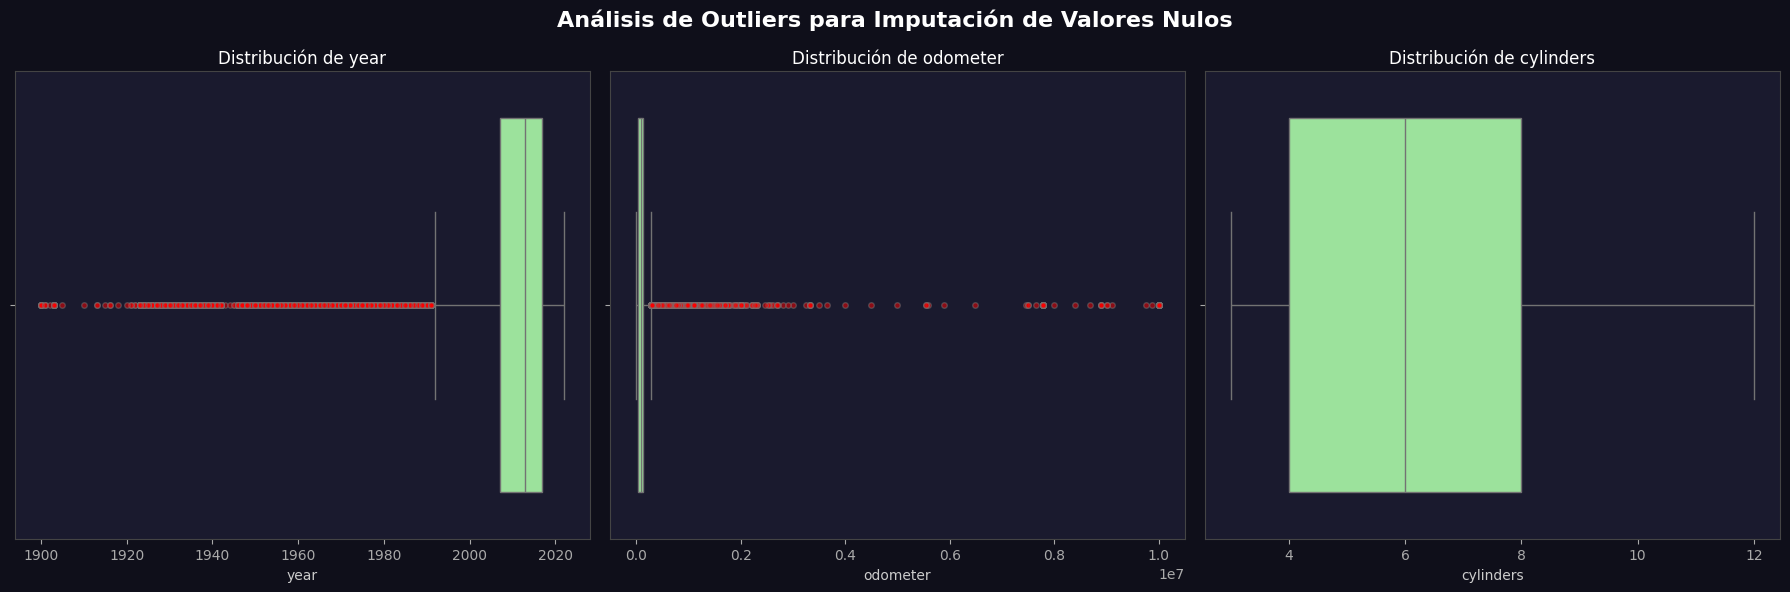

In [15]:
columnas_a_visualizar = ['year', 'odometer', 'cylinders']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análisis de Outliers para Imputación de Valores Nulos', fontsize=16, fontweight='bold')

for i, col in enumerate(columnas_a_visualizar):
    sns.boxplot(x=df_clean[col], ax=axes[i], color='lightgreen',
                flierprops=dict(markerfacecolor='red', marker='o', markersize=4, alpha=0.5))
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

>**Analisis**

En la columna `year`, existe una amplia dispersión de valores atípicos en anios anteriores a 1990, mientras que en `odometer` se observa una concentración extrema de datos cerca de cero junto a una larga "cola" de valores atípicos a la derecha.

Esta distribución asimétrica indica que el uso de la media para imputar valores nulos sería un error ya que los valores extremos sesgarían los resultados; por lo tanto, se debe utilizar la mediana como medida para imputar.

En cuanto a la columna `cylinders` su distribucion esta centrada en 4 a 8 cilindros, la media me daria un valor decimal que no esta entre los valores discretos de la variable, la mejor estrategia es imputar por la moda (6)

LAs columnas categoricas se imputaran con la moda

**Estrategia de imputacion**

| Columna | Nulos | % | Estrategia | Justificación |
| :--- | :--- | :--- | :--- | :--- |
| **size** | 175671	|68.03 | Eliminar | Excede el umbral del 50%, demasiada pérdida de información. |
| **cylinders** | 100655	|38.98	 | Moda | Variable discreta; la moda representa la mayoría de los motores. |
| **condition** | 95916	|37.15	 | Moda | Variable categórica ordinal; la moda es el estado más común. |
| **drive** | 77479	|30.01	 | Moda | Variable categórica nominal; imputar con la categoría predominante. |
| **paint_color** | 75032	|29.06	 | Moda | Variable categórica nominal; el color más frecuente. |
| **type** | 59663	|23.11 | Moda | Variable categórica; el tipo de vehículo más común. |
| **manufacturer** | 11347	|4.39	| Moda | Variable categórica; la marca con mayor presencia en el mercado. |
| **title_status** | 3961	|1.53	| Constante | Imputar como 'Clean' al ser la categoría dominante. |
| **odometer** | 2227	|0.86 | Mediana | Robusta ante valores extremos (*outliers*) en kilometraje. |
| **fuel** | 1537	|0.60 | Moda | Variable categórica; 'Gas' suele ser la categoría mayoritaria. |
| **transmission**| 1345|	0.52	| Moda | Variable categórica; 'Automatic' suele ser predominante. |
| **year** | 784	|0.30 | Mediana | La mediana es más precisa al evitar sesgos por años muy antiguos. |



> ## <font color='#1890A3'>**Paso 2.6 Imputaciones** </font>


In [16]:
# Imputamos con la mediana odometer y year

columnas_numericas_a_imputar = ['odometer', 'year']

for columna in columnas_numericas_a_imputar:
    nulos_antes = df_clean[columna].isnull().sum()
    mediana_calculada = df_clean[columna].median()
    df_clean[columna] = df_clean[columna].fillna(mediana_calculada)
    nulos_despues = df_clean[columna].isnull().sum()
    print(f"Columna '{columna}':")
    print(f"Nulos ANTES  : {nulos_antes}")
    print(f"Nulos DESPUÉS: {nulos_despues}\n")

Columna 'odometer':
Nulos ANTES  : 2227
Nulos DESPUÉS: 0

Columna 'year':
Nulos ANTES  : 784
Nulos DESPUÉS: 0



In [17]:
# Imputación por MODA (Variables categóricas y discretas)
cols_moda = ['cylinders', 'condition', 'drive', 'paint_color', 'type', 'manufacturer', 'fuel', 'transmission']

for col in cols_moda:
    if col in df_clean.columns:
        moda = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(moda)
        print(f"Columna '{col}': Imputada con moda '{moda}'")

Columna 'cylinders': Imputada con moda '6'
Columna 'condition': Imputada con moda 'Good'
Columna 'drive': Imputada con moda '4Wd'
Columna 'paint_color': Imputada con moda 'White'
Columna 'type': Imputada con moda 'Sedan'
Columna 'manufacturer': Imputada con moda 'Ford'
Columna 'fuel': Imputada con moda 'Gas'
Columna 'transmission': Imputada con moda 'Automatic'


In [18]:
# Eliminación de columna size con >50% de nulos ---
if 'size' in df_clean.columns:
    df_clean.drop(columns=['size'], inplace=True)
    print("Columna 'size' eliminada.")

Columna 'size' eliminada.


In [19]:
# imputación de (title_status) con clean
if 'title_status' in df_clean.columns:
    df_clean['title_status'] = df_clean['title_status'].fillna('Clean')
    print("Columna 'title_status': Imputada con constante 'Clean'")


Columna 'title_status': Imputada con constante 'Clean'


In [20]:
# Reporte final de nulos
print(f"Cantidad total de registros despues de tratamiento de nulos: {df_clean.shape[0]}")
print(f"Valores nulos en el dataset: {df_clean.isnull().sum().sum()}")

Cantidad total de registros despues de tratamiento de nulos: 258220
Valores nulos en el dataset: 0


> ## <font color='#1890A3'>**Paso 2.7 Identificar y Eliminar Outliers** </font>

En principio, todas las variables eran tipo object, asi que primero voy a ver la informacion estadistica de las variables convertidas a numericas

In [21]:
columnas_numericas = ['price', 'cylinders', 'odometer', 'year']
df_clean[columnas_numericas].describe()

,price,cylinders,odometer,year
count,2.582200e+05,258220.0,2.582200e+05,258220.0
mean,1.114638e+05,5.947429,1.036057e+05,2010.219967
std,1.566315e+07,1.256585,2.349074e+05,10.482945
min,0.000000e+00,3.0,0.000000e+00,1900.0
25%,5.500000e+03,6.0,4.114700e+04,2007.0
50%,1.250000e+04,6.0,9.084700e+04,2013.0
75%,2.399900e+04,6.0,1.384312e+05,2017.0
max,3.736929e+09,12.0,1.000000e+07,2022.0


`price` tiene valores minimos de cero y mas de 3000 millones de dolares. Si un auto vale cero probablemente sea chatarra o un auto incompleto, y un precio de 3000 millones de

`odometer` tiene valor minimo de cero y maximo de 10 millones de millas. Un valor cero debe ser de un auto nuevo o un error es mas real para un auto usado emplear un valor minimo de 1000 millas y como maximo 450.000 millas.

`year` esta entre 1900 y  2022, un rango muy amplio. Los autos anteriores a 1990 deben ser autos clasicos o de coleccion que tienen una relacion diferente con el precio (a mayor antiguedad  mas costosos), se filtrara la data para emplear solo el rango de 1990 a 2022

In [22]:
print('----- ANALISIS DE OUTLIERS / FILTROS -----')

filas_antes = len(df_clean)

# el precio debe estar entre 500 y 200 000 dolares
df_clean = df_clean[(df_clean['price'] >= 500) & (df_clean['price'] <= 200_000)].copy()


# el anio debe ser mayor o igual a 1990 y menor o igual al anio acutal
año_actual = 2026
df_clean = df_clean[(df_clean['year'] >= 1990) & (df_clean['year'] <= año_actual)].copy()

# el odometro debe tener valores entre 3000 y 300000 millas
df_clean = df_clean[(df_clean['odometer'] >= 3000) & (df_clean['odometer'] <= 300_000)].copy()

# Resumen de resultados
print(f'Rango precios : [{df_clean["price"].min():,.0f} – {df_clean["price"].max():,.0f}]')
print(f'Rango años    : [{df_clean["year"].min():.0f} – {df_clean["year"].max():.0f}]')
print(f'Rango odómetro: [{df_clean["odometer"].min():,.0f} – {df_clean["odometer"].max():,.0f}]')


print(f"\nRegistros antes del filtrado: {filas_antes:,}")
print(f'Registros DESPUÉS del filtro: {len(df_clean):,}')
print(f'Removidos: {filas_antes - len(df_clean):,} ({(filas_antes - len(df_clean))/filas_antes*100:.1f}%)')

----- ANALISIS DE OUTLIERS / FILTROS -----
Rango precios : [500 – 199,999]
Rango años    : [1990 – 2022]
Rango odómetro: [3,000 – 300,000]

Registros antes del filtrado: 258,220
Registros DESPUÉS del filtro: 219,518
Removidos: 38,702 (15.0%)


> ## <font color='#1890A3'>**Paso 2.8 Resumen proceso de Limpieza** </font>

In [23]:
print('------ RESUMEN DEL DATASET LIMPIO ------')
filas_finales, columnas_finales = df_clean.shape
print("---------------------------------------------------------")
print(f"Dimensiones Finales : {filas_finales} filas x {columnas_finales} columnas")
print(f"Valores Nulos Totales: {df_clean.isnull().sum().sum()} (¡Dataset 100% limpio!)")
print("---------------------------------------------------------")
print("Conteo de Variables por Tipo de Dato:")
print(df_clean.dtypes.value_counts())
print("---------------------------------------------------------")

------ RESUMEN DEL DATASET LIMPIO ------
---------------------------------------------------------
Dimensiones Finales : 219518 filas x 13 columnas
Valores Nulos Totales: 0 (¡Dataset 100% limpio!)
---------------------------------------------------------
Conteo de Variables por Tipo de Dato:
object     9
Int64      2
int64      1
float64    1
Name: count, dtype: int64
---------------------------------------------------------


# <font color='#1890A3'> **SECCION 3 EXPLORACION DE DATOS (EDA)**
**Univariante x2 | Multivariante x2 | Interpretacion** </font>

> ## <font color='#1890A3'>**Visualizacion Univariante 1 -- Histograma con KDE para Price**</font>

**Objetivo:** Entender la distribucion de la variable objetivo del analisis


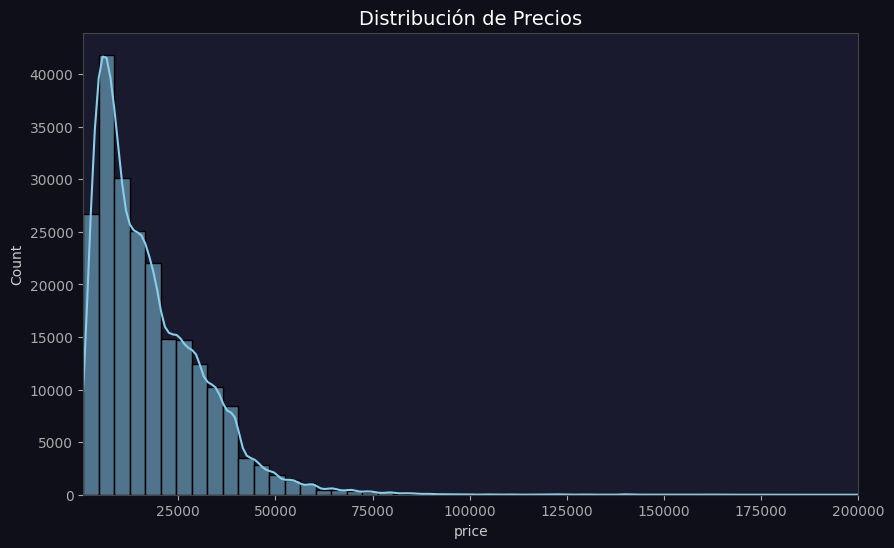

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['price'], kde=True, color='skyblue', bins=50)
plt.xlim(500, 200000)
plt.title('Distribución de Precios', fontsize=14)
plt.show()


> **Analisis**

El histograma muestra una distribución altamente asimétrica a la derecha (sesgada positivamente), la gran mayoría de las ventas se concentran en un rango de precios entre 0 y 25,000 USD.

La "cola" larga que se extiende hacia la derecha revela la presencia de autos de mayor valor o gama alta, con una frecuencia menor a medida que el precio aumenta.





> ## <font color='#1890A3'>**Visualizacion Univariante 2 -- Distribucion de las variables numericas**</font>

**Objetivo:** Entender la distribucion de los datos de las variables numericas `year`, `odometer`, `cylinders` para identificar tendencias y forma.

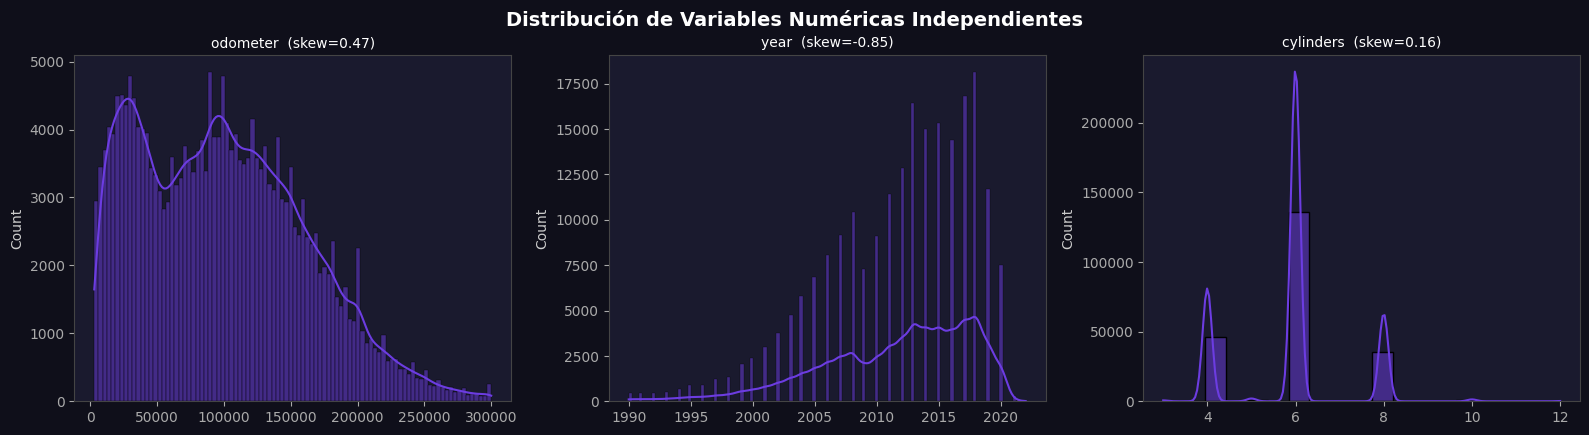

In [25]:
vars_num = ['odometer', 'year', 'cylinders']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribución de Variables Numéricas Independientes', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(vars_num):
    sns.histplot(data=df_clean, x=col, kde=True, ax=axes[i], color=PURPLE)
    skew_val = df_clean[col].skew()
    axes[i].set_title(f'{col}  (skew={skew_val:.2f})', fontsize=10)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

>**Analisis**

La grafica de `odometer` esta un poco sesgada a la derecha, se observa una amplia variedad en los valores de las millas con picos en valores especificos.

La grafica de `year` esta sesgada a la izquierda, hay mayor cantidad de registros a partir de los aios 2005 en adelante. Los registros crecen constantemente con algunas bajas en los anios 2010, 2014 al 16 y 2019.

La columna `cyliders` tiene valores discretos, concnetrados en 4, 6 y 8 cilindros, con la mayor cantidad de datos en 6 cilindros. Para el modelado, es mejor tratarla como variable categorica.

> ## <font color='#1890A3'>**Visualizacion Multivariante 1 -- Boxplot de Precio por anio de Fabricacion**</font>

**Objetivo:** Entender la relación entre el año de fabricación y el valor de mercado de los vehículos, permitiendo identificar tendencias  y el comportamiento de los precios a lo largo del tiempo.

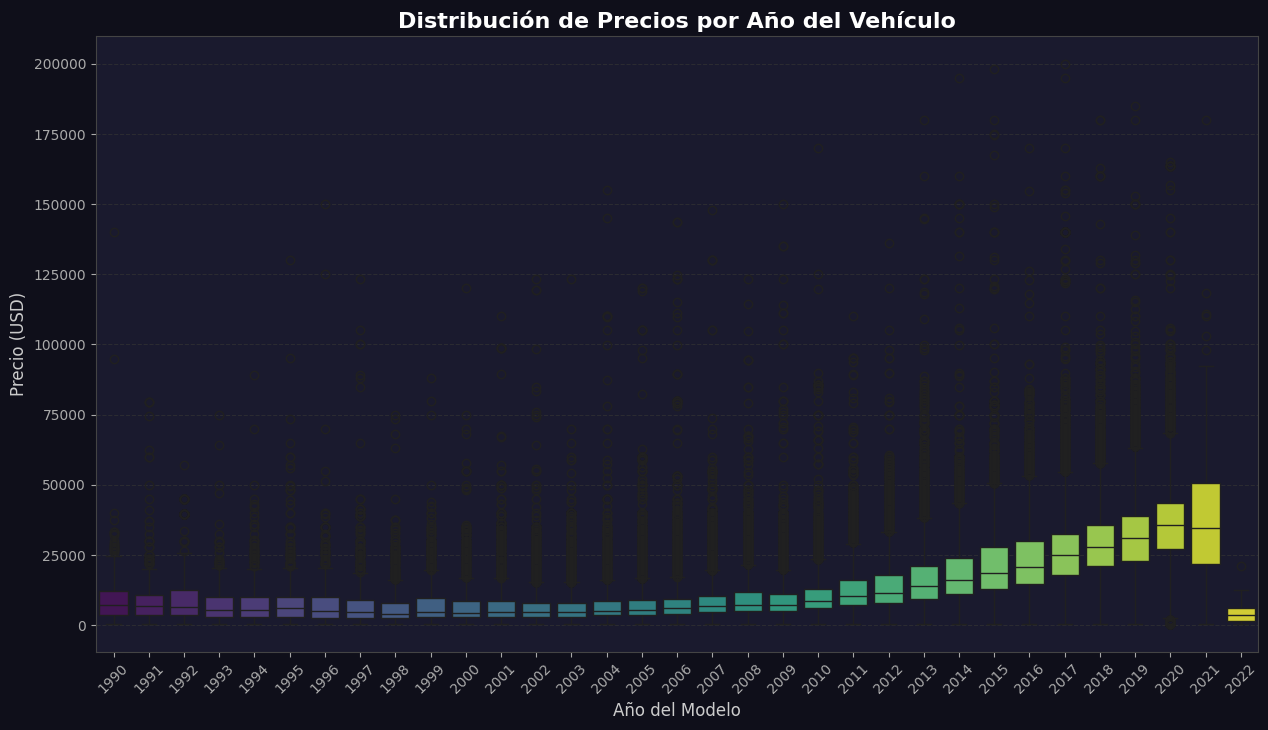

In [26]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='year', y='price', data=df_clean, palette='viridis')
plt.title('Distribución de Precios por Año del Vehículo', fontsize=16, fontweight='bold')
plt.xlabel('Año del Modelo', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

>**Analisis**

Los autos de anios mas recientes poseen medianas de precios más altas y la caja es mas grande, (especialmente a partir del 2011). La caja mas grande corresponde al 2021, donde se concentra el mayor volumen de datos.

Los modelos mas antiguos presentan precios similares y las cajas son mas chicas. La caja mas chica es del 2022, posiblemente porque no se tienen todos los datos de este anio.

> ## <font color='#1890A3'>**Visualizacion Multivariante 2 -- Boxplot de Precio por Marca (Top 10)**</font>

**Objetivo**: Comparar la distribución de los precios de las diez marcas de autos con mas registros del dataset

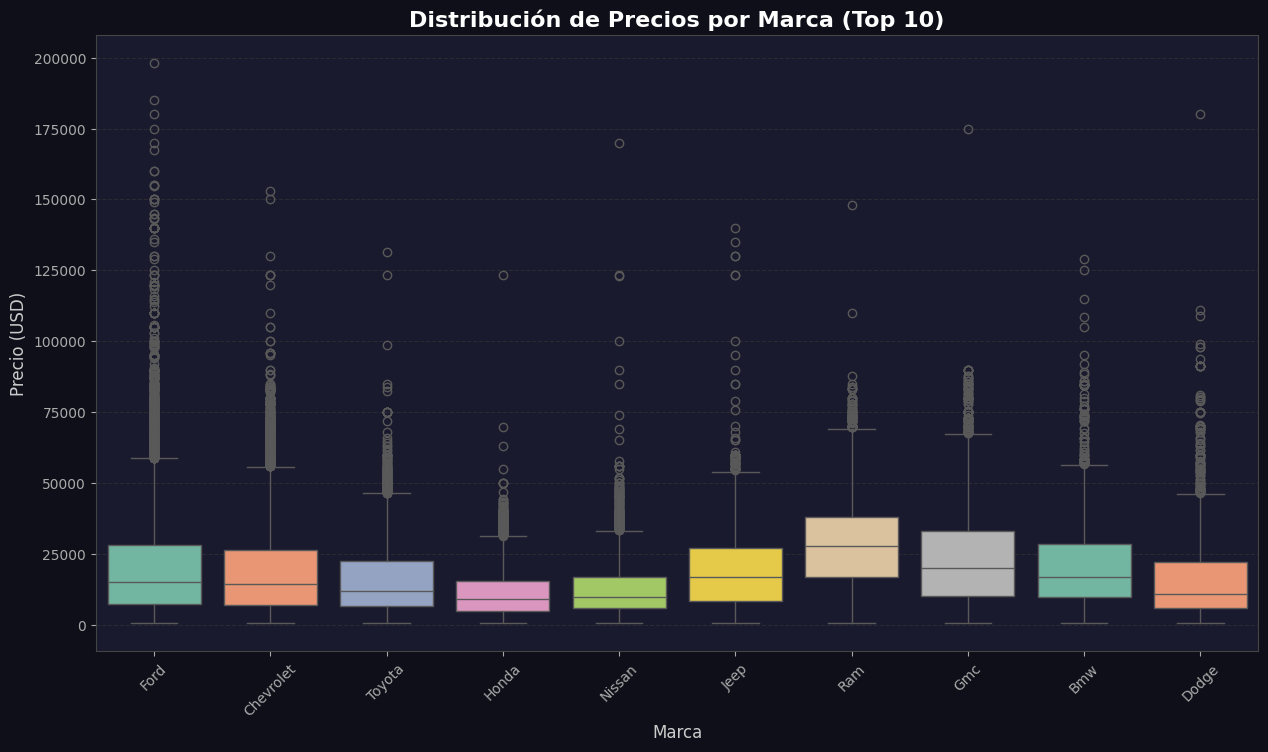

In [27]:
top_10_marcas = df_clean['manufacturer'].value_counts().nlargest(10).index
df_top_10 = df_clean[df_clean['manufacturer'].isin(top_10_marcas)]


plt.figure(figsize=(15, 8))
sns.boxplot(x='manufacturer', y='price', data=df_top_10, order=top_10_marcas, palette='Set2')
plt.title('Distribución de Precios por Marca (Top 10)', fontsize=16, fontweight='bold')
plt.xlabel('Marca', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


>**Analisis**

Las marcas como Ram y GMC presentan medianas de precio más altas, reflejando su enfoque en segmentos de mayor valor, mientras que marcas como Honda y Nissan muestran una concentración de precios más baja y uniforme.

La presencia masiva de outliers en todas las marcas indica que, independientemente de la fabricante, existen modelos de gama alta o versiones especiales que tienen un costo mayor al estándar del mercado.

> ## <font color='#1890A3'>**Visualizacion Multivariante 3 -- Heatmap de Correlaciones variables numéricas**</font>

**Objetivo:** Ver todas las correlaciones de las variables numericascdel dataset

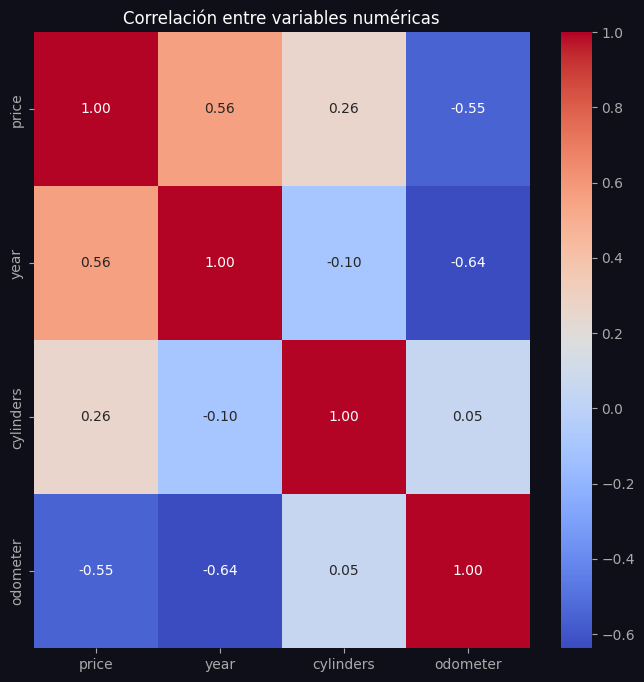

In [28]:
plt.figure(figsize=(8, 8))
matriz_corr = df_clean.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre variables numéricas')
plt.show()

>**Analisis**

La columna con `year` tiene una correlacion media con`price`(0.56) indicando que no siempre un auto mas nuevo es mas costoso, sino que un auto de lujo de mas de 10 anios de antiguedad, puede valer mas o igual que un auto nuevo. El valor del auto esta mas influenciado por variables como la marca o el modelo.

La  correlacion entre `odometer` y `price` es negativa (-0.55) a menor kilometraje mayor precio, es decir, los compradores pagan menos por autos con mayor kilometraje, lo que es razonable.

El numerod de `cylinders` tiene correlacion muy baja con `price`(0.26) indicando que el tamanio del motor no es una prioridad al momento de fijar el precio, el mercado probablemente valore mas el rendimiento del combustible que un motor mas grande (mas cilindros).

> ## <font color='#1890A3'>**Visualizacion Multivariante 4 -- ScatterPlot entre Millas recorridas y Precio**</font>

**Objetivo:** Evaluar la relación inversa entre el las millas recorridas (odometer) y el valor de los autos, para identificar como impacta el uso del auto en su precio.

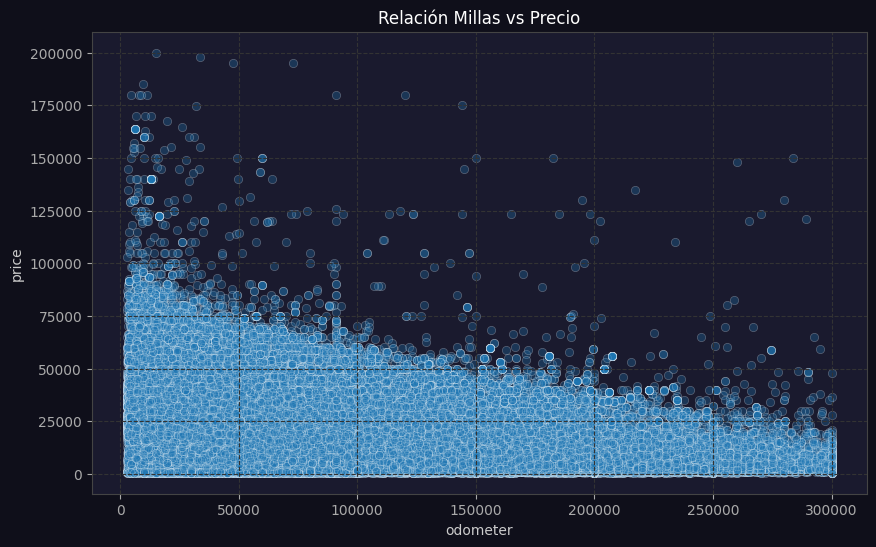

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='odometer', y='price', data=df_clean, alpha=0.3)
plt.title('Relación Millas vs Precio')
plt.grid(True)
plt.show()

> **Analisis**

Se observa que la mayor concentracion de precios esta en autos de bajas millas recorridas, a medida que aumentan las millas, el valor del auto disminuye rapidamente.

Sin embargo, tambien se observan puntos aislados con precios altos en valores de millas recorridas intermedio, lo que indica que por si solo el valor de las millas no es el unico factor determinante en el precio del auto.

> ## <font color='#1890A3'>**Visualizacion Multivariante 5 -- Boxplot de precio por tipo de vehiculo**</font>

**Objetivo:** Evaluar si el tipo de vehiculo influye en el precio del mismo permitiendo identificar qué segmentos poseen mayores precios medios y cómo se distribuye la variabilidad de costos dentro de cada clase.

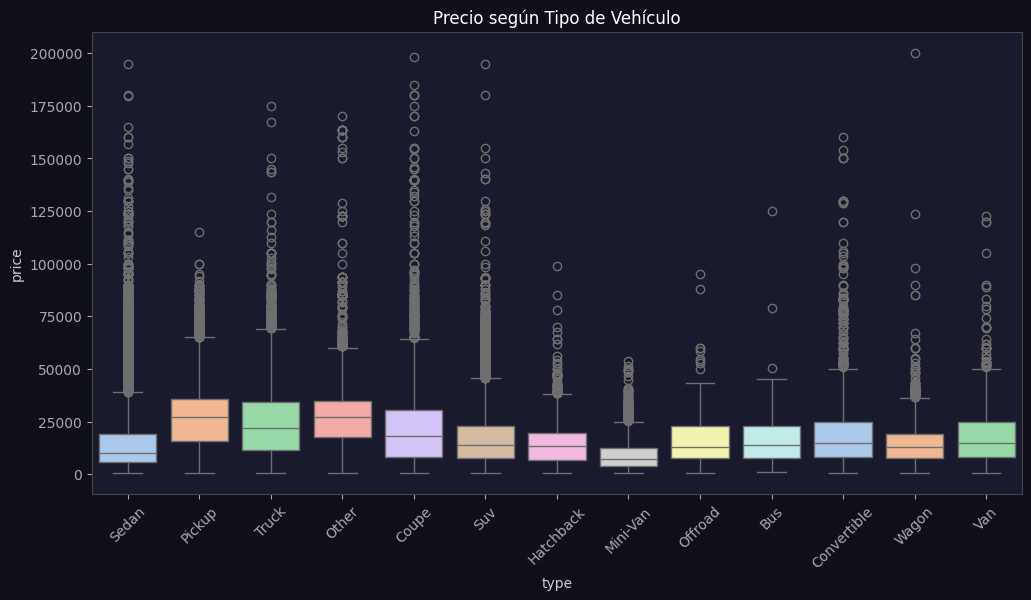

In [30]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='type', y='price', data=df_clean, palette='pastel')
plt.xticks(rotation=45)
plt.title('Precio según Tipo de Vehículo')
plt.show()

>**Analisis**

Los autos como pickup y trucks presentan medianas de precio muy superiores al resto, siendo los tipos mas costosos del dataset.

Los hatchback y mini-vans por el contrario tienen las valoraciones más bajas, lo que sugiere que hay poca demanda de autos de lujo en este segmento.

Hay abundantes outliers en todas las categorías, lo que hay ciertos modelos dentro de cada categoria que tienen un precio superior al resto

# <font color='#1890A3'> **SECCION 4 PREPROCESAMIENTO DE DATOS**
**Agrupacion | Encoding | Train/Test | Escalamiento** </font>

> ## <font color='#1890A3'>**Agrupacion de Categorias**</font>

In [31]:
print("Valores únicos en title_status:")
print(df_clean['title_status'].unique())
print("\nCantidad de nulos en title_status:")
print(df_clean['title_status'].isnull().sum())

Valores únicos en title_status:
['Clean' 'Rebuilt' 'Lien' 'Salvage' 'Missing' 'Parts Only']

Cantidad de nulos en title_status:
0


In [32]:
df_prep = df_clean.copy()

# Unificar condition para que los valores 'like new y new' queden agrupados en la ctegoria 'excellent'
if 'condition' in df_prep.columns:
    df_prep['condition'] = df_prep['condition'].replace({'like new':'excellent','new':'excellent'})

# en title, dejar solo las categorias 'clean y lien' para no tomar en cuenta 'salvage y parts_only' porque no corresponden a un auto completo
if 'title_status' in df_prep.columns:
    n_antes = len(df_prep)
    df_prep['title_status'] = df_prep['title_status'].str.title()
    df_prep = df_prep[df_prep['title_status'].isin(['Clean','Lien', 'Rebuilt'])].copy()
    print(f'Registros con título inválido eliminados: {n_antes - len(df_prep):,}')

# Agrupar en type categorias raros en 'other'
if 'type' in df_prep.columns:
    tipos_ok = ['sedan','suv','pickup','truck','coupe','hatchback',
                'wagon','van','convertible','mini-van','offroad','bus']
    df_prep['type'] = df_prep['type'].apply(lambda x: x if x in tipos_ok else 'other')

# Reconvertir cylinders a categorico despues del analisis y graficos
if 'cylinders' in df_prep.columns:
    df_prep['cylinders'] = df_prep['cylinders'].astype(str)
    print("Variable 'cylinders' convertida a categórica.")

print(f'\nShape final: {df_prep.shape}')

Registros con título inválido eliminados: 3,051
Variable 'cylinders' convertida a categórica.

Shape final: (216467, 13)


> ## <font color='#1890A3'>**Train - Test Split**</font>


In [33]:
from sklearn.model_selection import train_test_split

if len(df_prep) == 0:
    print("Error: Tu dataset está vacío. Revisa los filtros previos.")
else:
    X = df_prep.drop(columns=['price'])
    y = df_prep['price']

    # Reducción de muestra por uso de memoria ram al procesar muestra completa
    if len(X) > 80_000:
        X, _, y, _ = train_test_split(X, y, train_size=80_000, random_state=42)
        print(f'Muestra de trabajo: {len(X):,} registros (representativa)')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
    print(f'y_train : {y_train.shape}  |  y_test : {y_test.shape}')


Muestra de trabajo: 80,000 registros (representativa)
X_train : (64000, 12)  |  X_test : (16000, 12)
y_train : (64000,)  |  y_test : (16000,)


> ## <font color='#1890A3'>**Pipeline con Column Transformer**</font>

In [34]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

cols_num = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
cols_cat = X_train.select_dtypes(include='object').columns.tolist()

print(f'Columnas numéricas ({len(cols_num)}): {cols_num}')
print(f'Columnas categóricas ({len(cols_cat)}): {cols_cat}')

# Pipelines individuales
pipe_num = make_pipeline(
    SimpleImputer(strategy='median'),
    MinMaxScaler()
)

pipe_cat = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
)

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', pipe_num, cols_num),
    ('cat', pipe_cat, cols_cat)
])

print('\n✅ Preprocessor definido:')
print(preprocessor)


Columnas numéricas (2): ['year', 'odometer']
Columnas categóricas (10): ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']

✅ Preprocessor definido:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('minmaxscaler',
                                                  MinMaxScaler())]),
                                 ['year', 'odometer']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                   

> ## <font color='#1890A3'>**Benchmarking**</font>

In [36]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import  RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline, make_pipeline

# ── Diccionario de modelos con sus pipelines
modelos = {
    'Lineal'       : Pipeline([('pre', preprocessor), ('model', LinearRegression())]),
    'Ridge'        : Pipeline([('pre', preprocessor), ('model', Ridge(alpha=1.0))]),
    'Lasso'        : Pipeline([('pre', preprocessor), ('model', Lasso(alpha=0.1))]),
    'Random Forest': Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=42))]),
}

# ── Entrenar y evaluar
resultados = []
for nombre, pipeline in modelos.items():
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    t_fit = time.time() - t0

    pred = pipeline.predict(X_test)
    pred_tr = pipeline.predict(X_train)

    resultados.append({
        'Modelo'    : nombre,
        'R² Train'  : round(r2_score(y_train, pred_tr), 4),
        'R² Test'   : round(r2_score(y_test,  pred),    4),
        'RMSE (USD)': round(np.sqrt(mean_squared_error(y_test, pred)), 0),
        'MAE (USD)' : round(mean_absolute_error(y_test, pred), 0),
        'Tiempo (s)': round(t_fit, 1),
        '_pred'     : pred
    })
    print(f'{nombre:15s}: R²={resultados[-1]["R² Test"]:.4f}  RMSE=${resultados[-1]["RMSE (USD)"]:,.0f}  ({t_fit:.1f}s)')

tabla = pd.DataFrame([{k:v for k,v in r.items() if k!='_pred'} for r in resultados])
tabla = tabla.sort_values('R² Test', ascending=False).reset_index(drop=True)

Lineal         : R²=0.6381  RMSE=$8,379  (2.0s)
Ridge          : R²=0.6381  RMSE=$8,379  (1.1s)
Lasso          : R²=0.6381  RMSE=$8,378  (22.0s)
Random Forest  : R²=0.7147  RMSE=$7,439  (67.8s)


> ## <font color='#1890A3'>**Tabla de Resultados**</font>

In [37]:
display(tabla.style
        .background_gradient(subset=['R² Test'], cmap='Greens')
        .background_gradient(subset=['RMSE (USD)','MAE (USD)'], cmap='Reds_r')
        .background_gradient(subset=['Tiempo (s)'], cmap='Blues_r')
        .format({'RMSE (USD)':'${:,.0f}', 'MAE (USD)':'${:,.0f}',
                 'R² Train':'{:.4f}', 'R² Test':'{:.4f}'}))

mejor_nombre = tabla.loc[0, 'Modelo']
print(f'\n🏆 Mejor modelo: {mejor_nombre}  (R²={tabla.loc[0,"R² Test"]:.4f})')

,Modelo,R² Train,R² Test,RMSE (USD),MAE (USD),Tiempo (s)
0,Random Forest,0.7838,0.7147,"$7,439","$4,393",67.800000
1,Lineal,0.6244,0.6381,"$8,379","$5,550",2.000000
2,Ridge,0.6243,0.6381,"$8,379","$5,550",1.100000
3,Lasso,0.6244,0.6381,"$8,378","$5,549",22.000000



🏆 Mejor modelo: Random Forest  (R²=0.7147)


> ## <font color='#1890A3'>**Exploracion con Lazy Predict**</font>

In [38]:
!pip install lazypredict --quiet

In [39]:
try:
    from lazypredict.Supervised import LazyRegressor

    X_train_enc = preprocessor.fit_transform(X_train)
    X_test_enc  = preprocessor.transform(X_test)

    np.random.seed(42)
    idx = np.random.choice(len(X_train_enc), size=3000, replace=False)
    X_lz_train = X_train_enc[idx]
    y_lz_train = y_train.iloc[idx]

    reg = LazyRegressor(verbose=0, ignore_warnings=True, predictions=False)
    models_lazy, _ = reg.fit(X_lz_train, X_test_enc, y_lz_train, y_test)

    print('Top 15 modelos según LazyPredict:')
    display(models_lazy.head(15))

except ImportError:
    print('LazyPredict no está instalado.')
    print('Ejecuta: !pip install lazypredict --quiet')
    print('Luego reinicia el kernel y ejecuta esta celda de nuevo.')
except Exception as e:
    print(f'Error en LazyPredict: {e}')
    print('Continúa con los resultados del benchmark manual.')

Top 15 modelos según LazyPredict:


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
LGBMRegressor,0.657652,0.660198,8118.877915,0.661558
HistGradientBoostingRegressor,0.656404,0.658960,8133.658986,4.379304
GradientBoostingRegressor,0.643434,0.646086,8285.752525,1.589169
XGBRegressor,0.634317,0.637037,8391.017578,0.863835
RandomForestRegressor,0.631737,0.634476,8420.568681,3.694937
PoissonRegressor,0.625537,0.628323,8491.148627,0.219459
ExtraTreesRegressor,0.619112,0.621945,8563.690239,9.674302
LassoLarsIC,0.590587,0.593632,8878.568532,0.272737
LarsCV,0.590483,0.593529,8879.697062,0.601532


El modelo de HistGradientBoostingRegressor es el ganador, con un $R^2$ de 0.667 (lo que significa que explica aproximadamente el 66.7% de la variabilidad del precio de los autos).

Los modelos Histogram Boosting, LGBM, Gradient Boosting, Random Forest, XGBoost estan en el top 5. Esto confirma que los datos tienen relaciones no lineales complejas que los modelos lineales simples (como Lasso o BayesianRidge) no alcanzan a capturar.

> ## <font color='#1890A3'>**OPTIMIZACIÓN CON GridSearchCV**</font>

In [41]:
import time
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [150, 250],
    'model__max_depth': [15, 20, 25],
    'model__min_samples_leaf': [1, 2, 4]
}

pipe_base = modelos['Random Forest']

t0 = time.time()

grid_search = GridSearchCV(
    estimator=pipe_base,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train, y_train)

elapsed = time.time() - t0

print(f'\nGridSearchCV completado en {elapsed/60:.1f} minutos')
print(f'Mejor R² CV (train): {grid_search.best_score_:.4f}')
print(f'\nMejores hiperparámetros:')
for k, v in grid_search.best_params_.items():
    print(f'  {k:35s}: {v}')


Fitting 3 folds for each of 18 candidates, totalling 54 fits

GridSearchCV completado en 96.4 minutos
Mejor R² CV (train): 0.7348

Mejores hiperparámetros:
  model__max_depth                   : 25
  model__min_samples_leaf            : 2
  model__n_estimators                : 250


El modelo incremento el R2 de 0.7147 a 0.7348


In [42]:
#combinaciones
cv_results = pd.DataFrame(grid_search.cv_results_)

columnas_interes = [
    'param_model__n_estimators',
    'param_model__max_depth',
    'param_model__min_samples_leaf',
    'mean_test_score',
    'std_test_score',
    'mean_fit_time'
]
cv_results = cv_results[columnas_interes].sort_values('mean_test_score', ascending=False)

cv_results.columns = [
    'n_estimators', 'max_depth', 'min_samples_leaf',
    'R² CV (media)', 'R² CV (std)', 'Tiempo (s)'
]

print('Top 10 mejores combinaciones:')
display(cv_results.head(10).style
        .background_gradient(subset=['R² CV (media)'], cmap='Greens')
        .format({
            'R² CV (media)': '{:.4f}',
            'R² CV (std)': '{:.4f}',
            'Tiempo (s)': '{:.1f}'
        }))

Top 10 mejores combinaciones:


,n_estimators,max_depth,min_samples_leaf,R² CV (media),R² CV (std),Tiempo (s)
15,250,25,2,0.7348,0.0067,276.3
14,150,25,2,0.7344,0.0068,168.8
13,250,25,1,0.7323,0.0049,285.0
12,150,25,1,0.7322,0.0048,186.0
9,250,20,2,0.7310,0.0069,262.7
8,150,20,2,0.7307,0.0071,156.1
6,150,20,1,0.7286,0.0049,167.3
7,250,20,1,0.7286,0.0050,266.0
17,250,25,4,0.7240,0.0074,221.6
16,150,25,4,0.7237,0.0076,154.1


Los resultados confirman que con (n_estimators: 250, max_depth: 25, min_samples_leaf: 2) se logra el mayor rendimiento demostrando que una mayor profundidad y un número intermedio de hojas son clave para maximizar la precisión de los datos

**La diferencia de rendimiento entre usar 150 y 250 árboles es minima (0.7344 vs 0.7348), y casi un 40% más rápida (168.8s vs 276.3s), por lo que sería la opción más eficiente para despliegue en producción sin sacrificar capacidad predictiva**

Hay una baja desviación estándar ($\approx 0.006$) en todas las combinaciones superiores, lo que indica que el modelo es robusto.

> ## <font color='#1890A3'>**Evaluacion del Modleo Optimizado**</font>

In [43]:
mejor_modelo = grid_search.best_estimator_
pred_opt_train = mejor_modelo.predict(X_train)
pred_opt_test  = mejor_modelo.predict(X_test)

r2_opt_tr  = r2_score(y_train, pred_opt_train)
r2_opt_te  = r2_score(y_test,  pred_opt_test)
rmse_opt   = np.sqrt(mean_squared_error(y_test, pred_opt_test))
mae_opt    = mean_absolute_error(y_test, pred_opt_test)

print('═══ MODELO FINAL OPTIMIZADO ════════════════════')
print(f'Hiperparámetros: {grid_search.best_params_}')
print(f'R² Train        : {r2_opt_tr:.4f}')
print(f'R² Test         : {r2_opt_te:.4f}')
print(f'RMSE            : ${rmse_opt:,.0f}')
print(f'MAE             : ${mae_opt:,.0f}')

═══ MODELO FINAL OPTIMIZADO ════════════════════
Hiperparámetros: {'model__max_depth': 25, 'model__min_samples_leaf': 2, 'model__n_estimators': 250}
R² Train        : 0.8944
R² Test         : 0.7440
RMSE            : $7,046
MAE             : $4,011


> ## <font color='#1890A3'>**TABLA DE RESULTADOS CON TODOS LOS MODELOS**</font>

In [45]:
fila_opt = {
    'Modelo'    : 'RF Optimizado ⭐',
    'R² Train'  : round(r2_opt_tr, 4),
    'R² Test'   : round(r2_opt_te, 4),
    'RMSE (USD)': round(rmse_opt, 0),
    'MAE (USD)' : round(mae_opt, 0),
    'Tiempo (s)': 5784  # 96.4 minutos * 60 segundos
}
tabla_final = pd.concat([tabla, pd.DataFrame([fila_opt])], ignore_index=True)
tabla_final = tabla_final.sort_values('R² Test', ascending=False).reset_index(drop=True)

display(tabla_final.style
        .background_gradient(subset=['R² Test'], cmap='Greens')
        .background_gradient(subset=['RMSE (USD)','MAE (USD)'], cmap='Reds_r')
        .format({'RMSE (USD)':'${:,.0f}', 'MAE (USD)':'${:,.0f}',
                 'R² Train':'{:.4f}', 'R² Test':'{:.4f}'}))

,Modelo,R² Train,R² Test,RMSE (USD),MAE (USD),Tiempo (s)
0,RF Optimizado ⭐,0.8944,0.7440,"$7,046","$4,011",5784.000000
1,Random Forest,0.7838,0.7147,"$7,439","$4,393",67.800000
2,Lineal,0.6244,0.6381,"$8,379","$5,550",2.000000
3,Ridge,0.6243,0.6381,"$8,379","$5,550",1.100000
4,Lasso,0.6244,0.6381,"$8,378","$5,549",22.000000


> ## <font color='#1890A3'>**GUARDADO DEL MODELO**</font>

In [47]:
import joblib

joblib.dump(mejor_modelo, 'rf_precio_autos_v1.pkl')
print('✅ Modelo guardado: rf_precio_autos_v1.pkl')



✅ Modelo guardado: rf_precio_autos_v1.pkl


> ## <font color='#1890A3'>**PREDICCION EN PRODUCCION - AUTO CREADO**</font>

In [50]:
print('\n── Ejemplo de predicción con el modelo guardado ──')
modelo_cargado = joblib.load('rf_precio_autos_v1.pkl')

nuevo_auto = pd.DataFrame([{
    'year': 2019, 'manufacturer': 'toyota', 'condition': 'good',
    'cylinders': '4 cylinders', 'fuel': 'gas', 'odometer': 45000,
    'transmission': 'automatic', 'drive': 'fwd','title_status':'clean',
    'type': 'sedan', 'paint_color': 'white', 'state': 'ca'
}])

precio_predicho = modelo_cargado.predict(nuevo_auto)[0]
print(f'Toyota Camry 2019, 45.000 millas, buen estado:')
print(f'  Precio estimado: ${precio_predicho:,.0f} USD')


── Ejemplo de predicción con el modelo guardado ──
Toyota Camry 2019, 45.000 millas, buen estado:
  Precio estimado: $59,939 USD
